In [5]:
import numpy as np
import pandas as pd

import io
import os
import tensorflow as tf

from PIL import Image
from glob import glob
import itertools

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, BatchNormalization, Dropout, Dense, MaxPool2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from IPython.display import display
#To see the value of multiple statements at once.
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [6]:
""" import os
import shutil
import pandas as pd

# Paths
image_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\images"
metadata_path = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\metadata.csv"

# ✅ Updated output path
output_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\sorted images"

# Read metadata
df = pd.read_csv(metadata_path)

# Process each image
for _, row in df.iterrows():
    isic_id = row['isic_id'].strip()
    label = str(row['diagnosis']).strip().replace("/", "-")

    filename = f"{isic_id}.jpg"
    src_path = os.path.join(image_dir, filename)
    dst_folder = os.path.join(output_dir, label)
    dst_path = os.path.join(dst_folder, filename)

    os.makedirs(dst_folder, exist_ok=True)

    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
    else:
        print(f"Missing file: {filename}")
 """

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 70-71: truncated \UXXXXXXXX escape (523872643.py, line 31)

# read the data

=== Loading HIBA Dataset ===
Base directory: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\sorted images
No CSV metadata file found. Creating basic structure from image files...
Created DataFrame with 1386 images

=== Preprocessing Data ===
Removed 0 rows with missing diagnosis
Diagnosis mapping: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'seborrheic keratosis': 5, 'solar lentigo': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}
Found 1386/1386 valid image paths
Final dataset: 1386 samples with 9 unique diagnoses

=== Dataset Summary ===
Total samples: 1386
Total unique diagnoses: 9
Columns: ['isic_id', 'diagnosis', 'image_path', 'diagnosis_label']

No missing values found

Data types:
  isic_id: object
  diagnosis: object
  image_path: object
  diagnosis_label: int64

=== Dataset Analysis ===
Class distribution:
  

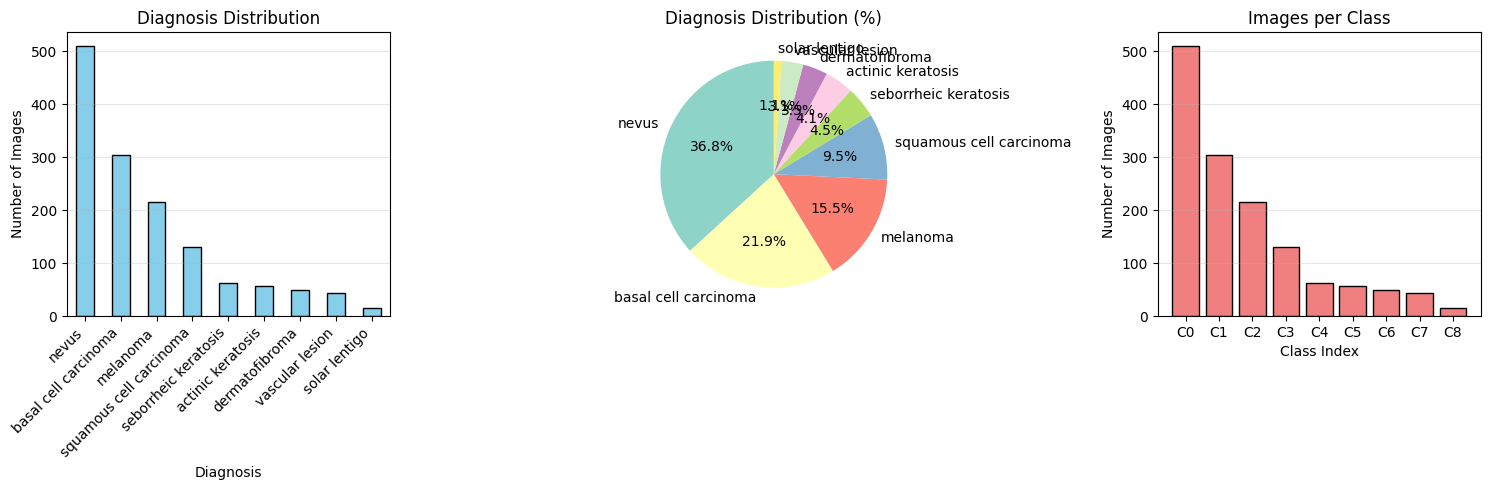


=== Visualizing Sample Images ===
Found 9 unique diagnoses


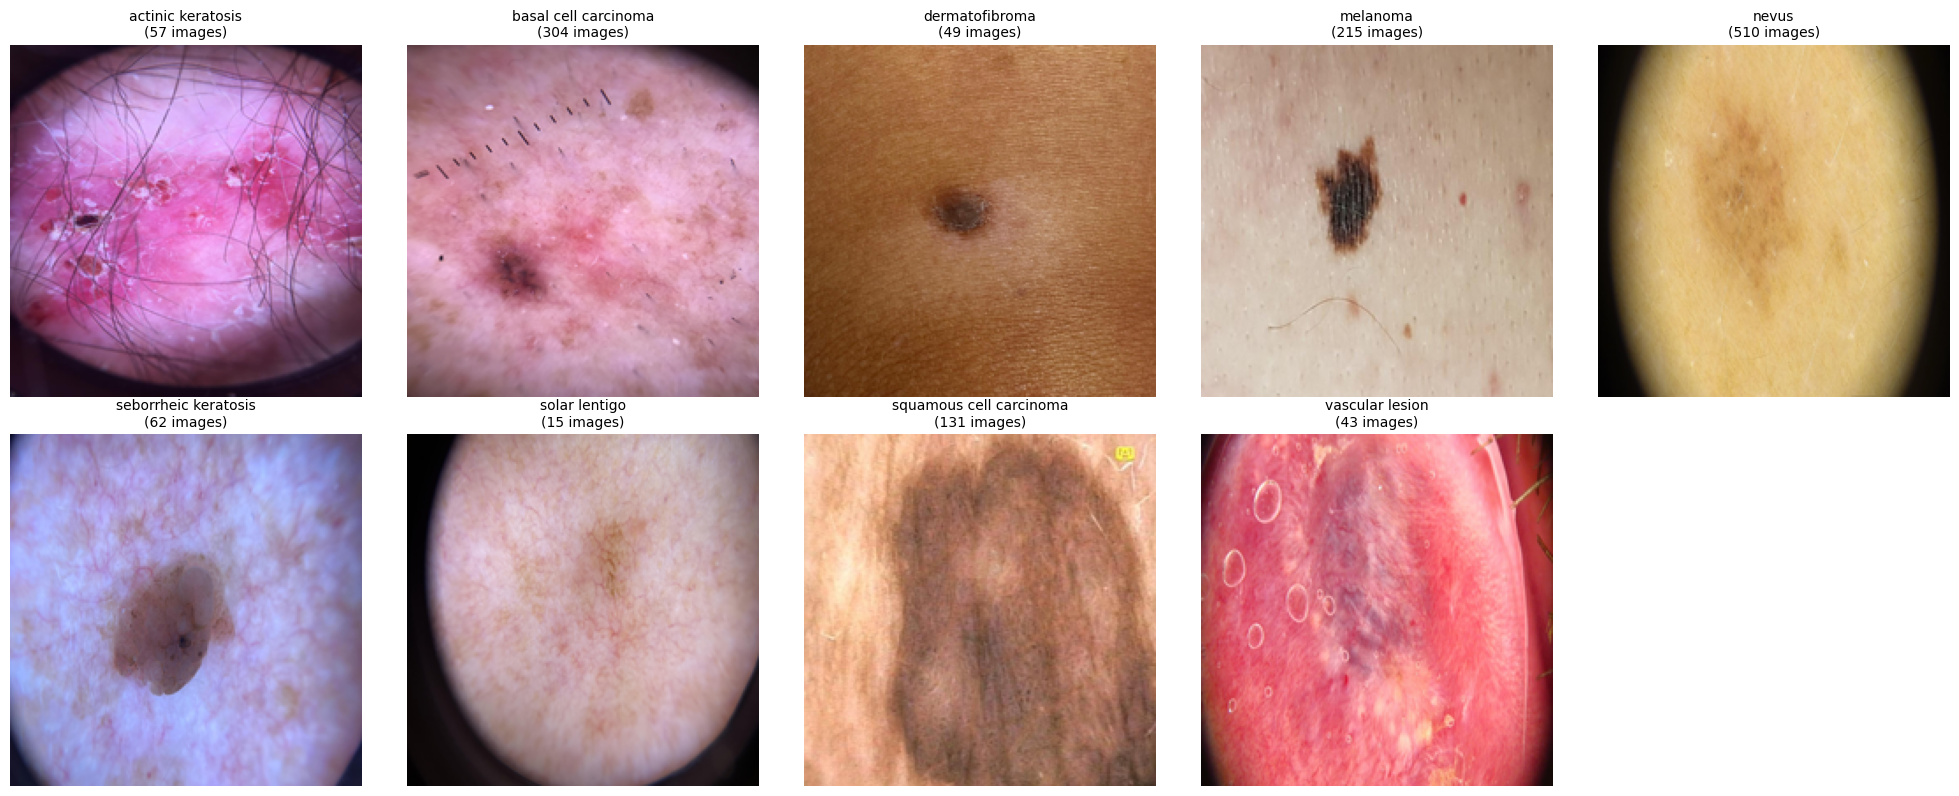


Dataset exploration complete!
Final dataset shape: (1386, 4)


In [7]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

def load_hiba_dataset(base_dir):
    """Load and explore the HIBA dataset structure"""
    print("=== Loading HIBA Dataset ===")
    print(f"Base directory: {base_dir}")
    
    # Check if base directory exists
    if not os.path.exists(base_dir):
        print(f"ERROR: Base directory does not exist: {base_dir}")
        return None
    
    # Look for CSV metadata file
    csv_files = glob(os.path.join(base_dir, "*.csv"))
    if csv_files:
        print(f"Found CSV files: {csv_files}")
        # Load the first CSV file found
        df = pd.read_csv(csv_files[0])
        print(f"Loaded CSV with {len(df)} rows and {df.shape[1]} columns")
        print(f"Columns: {list(df.columns)}")
    else:
        print("No CSV metadata file found. Creating basic structure from image files...")
        df = create_basic_dataframe_from_images(base_dir)
    
    return df

def create_basic_dataframe_from_images(base_dir):
    """Create a basic DataFrame from image files if no CSV is available"""
    # Look for image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']
    all_images = []
    
    for ext in image_extensions:
        all_images.extend(glob(os.path.join(base_dir, ext)))
        all_images.extend(glob(os.path.join(base_dir, "**", ext), recursive=True))
    
    if not all_images:
        print("No images found!")
        return None
    
    # Create basic DataFrame
    data_list = []
    for img_path in all_images:
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        
        # Try to infer diagnosis from folder structure
        parent_dir = os.path.basename(os.path.dirname(img_path))
        if parent_dir != os.path.basename(base_dir):
            diagnosis = parent_dir
        else:
            diagnosis = 'unknown'
        
        data_list.append({
            'isic_id': img_name,
            'diagnosis': diagnosis,
            'image_path': img_path
        })
    
    df = pd.DataFrame(data_list)
    print(f"Created DataFrame with {len(df)} images")
    return df

def preprocess_hiba_data(df, base_dir):
    """Preprocess the HIBA dataset"""
    print("\n=== Preprocessing Data ===")
    
    if df is None:
        return None
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Check if 'diagnosis' column exists
    if 'diagnosis' not in df.columns:
        print("No 'diagnosis' column found. Looking for alternative diagnosis columns...")
        
        # Look for potential diagnosis columns
        potential_cols = [col for col in df.columns if 'diagnosis' in col.lower()]
        if potential_cols:
            print(f"Found potential diagnosis columns: {potential_cols}")
            df['diagnosis'] = df[potential_cols[0]]
        else:
            print("No diagnosis information found. Creating dummy diagnosis...")
            df['diagnosis'] = 'unknown'
    
    # Drop rows with missing diagnosis
    initial_count = len(df)
    df.dropna(subset=['diagnosis'], inplace=True)
    print(f"Removed {initial_count - len(df)} rows with missing diagnosis")
    
    # Encode 'diagnosis' to numeric labels
    diagnosis_mapping = {label: idx for idx, label in enumerate(df['diagnosis'].unique())}
    df['diagnosis_label'] = df['diagnosis'].map(diagnosis_mapping)
    
    print(f"Diagnosis mapping: {diagnosis_mapping}")
    
    # Create image_path if it doesn't exist
    if 'image_path' not in df.columns:
        if 'isic_id' in df.columns:
            df['image_path'] = df['isic_id'].apply(lambda x: find_image_path(x, base_dir))
        else:
            print("WARNING: Cannot create image paths - no 'isic_id' column found")
            return df
    
    # Check if image paths exist
    existing_paths = df['image_path'].apply(lambda x: os.path.exists(x) if pd.notna(x) else False)
    valid_count = existing_paths.sum()
    print(f"Found {valid_count}/{len(df)} valid image paths")
    
    # Keep only rows with valid image paths
    df = df[existing_paths].copy()
    
    # Drop unnecessary columns safely
    columns_to_drop = ['attribution', 'copyright_license', 'anatom_site_general', 'anatom_site_special',
                       'benign_malignant', 'concomitant_biopsy', 'dermoscopic_type','diagnosis_1', 'diagnosis_2', 'diagnosis_3',
                       'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id',
                       'patient_id', 'personal_hx_mm', 'sex']
    
    # Only drop columns that actually exist
    existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
    if existing_columns_to_drop:
        df.drop(columns=existing_columns_to_drop, inplace=True)
        print(f"Dropped columns: {existing_columns_to_drop}")
    
    print(f"Final dataset: {len(df)} samples with {len(df['diagnosis'].unique())} unique diagnoses")
    
    return df

def find_image_path(image_id, base_dir):
    """Find the full path for an image ID"""
    image_extensions = ['jpg', 'jpeg', 'png', 'bmp', 'tiff']
    
    for ext in image_extensions:
        # Try different possible paths
        possible_paths = [
            os.path.join(base_dir, f"{image_id}.{ext}"),
            os.path.join(base_dir, "**", f"{image_id}.{ext}")
        ]
        
        for path_pattern in possible_paths:
            matches = glob(path_pattern, recursive=True)
            if matches:
                return matches[0]
    
    return None

def analyze_dataset_distribution(df):
    """Analyze and visualize the dataset distribution"""
    print("\n=== Dataset Analysis ===")
    
    if df is None or len(df) == 0:
        print("No data to analyze")
        return
    
    # Class distribution
    class_counts = df['diagnosis'].value_counts()
    print("Class distribution:")
    for diagnosis, count in class_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {diagnosis}: {count} images ({percentage:.1f}%)")
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    # Bar plot
    plt.subplot(1, 3, 1)
    class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Diagnosis Distribution')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Pie chart
    plt.subplot(1, 3, 2)
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
    plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
    plt.title('Diagnosis Distribution (%)')
    
    # Box plot of class sizes (if meaningful)
    plt.subplot(1, 3, 3)
    plt.bar(range(len(class_counts)), class_counts.values, color='lightcoral', edgecolor='black')
    plt.title('Images per Class')
    plt.xlabel('Class Index')
    plt.ylabel('Number of Images')
    plt.xticks(range(len(class_counts)), [f"C{i}" for i in range(len(class_counts))])
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return class_counts

def visualize_sample_images(df, max_samples_per_class=1):
    """Visualize sample images for each diagnosis"""
    print(f"\n=== Visualizing Sample Images ===")
    
    if df is None or len(df) == 0:
        print("No data to visualize")
        return
    
    unique_diagnoses = df['diagnosis'].unique()
    n_diagnoses = len(unique_diagnoses)
    
    print(f"Found {n_diagnoses} unique diagnoses")
    
    # Calculate grid size
    cols = min(5, n_diagnoses)
    rows = (n_diagnoses + cols - 1) // cols
    
    plt.figure(figsize=(4*cols, 4*rows))
    
    for i, diagnosis in enumerate(unique_diagnoses):
        # Get samples for this diagnosis
        diagnosis_samples = df[df['diagnosis'] == diagnosis]
        
        if len(diagnosis_samples) == 0:
            continue
        
        # Take up to max_samples_per_class
        samples_to_show = min(max_samples_per_class, len(diagnosis_samples))
        
        for j in range(samples_to_show):
            sample_image = diagnosis_samples.iloc[j]
            img_path = sample_image['image_path']
            
            try:
                # Load and display image
                img = Image.open(img_path)
                
                # Convert to RGB if necessary
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Resize for consistent display
                img = img.resize((200, 200), Image.LANCZOS)
                
                plt.subplot(rows, cols, i + 1)
                plt.imshow(img)
                plt.title(f"{diagnosis}\n({len(diagnosis_samples)} images)", fontsize=10)
                plt.axis("off")
                
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
                plt.subplot(rows, cols, i + 1)
                plt.text(0.5, 0.5, f"Error loading\n{diagnosis}", 
                        ha='center', va='center', transform=plt.gca().transAxes)
                plt.title(f"{diagnosis}\n({len(diagnosis_samples)} images)", fontsize=10)
                plt.axis("off")
    
    plt.tight_layout()
    plt.show()

def generate_dataset_summary(df):
    """Generate a comprehensive dataset summary"""
    print("\n=== Dataset Summary ===")
    
    if df is None:
        print("No dataset loaded")
        return
    
    print(f"Total samples: {len(df)}")
    print(f"Total unique diagnoses: {len(df['diagnosis'].unique())}")
    print(f"Columns: {list(df.columns)}")
    
    # Missing values
    missing_data = df.isnull().sum()
    if missing_data.sum() > 0:
        print("\nMissing values:")
        for col, missing_count in missing_data.items():
            if missing_count > 0:
                print(f"  {col}: {missing_count}")
    else:
        print("\nNo missing values found")
    
    # Data types
    print(f"\nData types:")
    for col, dtype in df.dtypes.items():
        print(f"  {col}: {dtype}")

def main():
    """Main function to run the HIBA dataset exploration"""
    # Set the base directory
    base_skin_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\sorted images"
    
    # Load dataset
    df = load_hiba_dataset(base_skin_dir)
    
    if df is None:
        print("Failed to load dataset")
        return None
    
    # Preprocess data
    df = preprocess_hiba_data(df, base_skin_dir)
    
    if df is None or len(df) == 0:
        print("No valid data after preprocessing")
        return None
    
    # Generate summary
    generate_dataset_summary(df)
    
    # Analyze distribution
    class_counts = analyze_dataset_distribution(df)
    
    # Visualize samples
    visualize_sample_images(df, max_samples_per_class=1)
    
    print(f"\nDataset exploration complete!")
    print(f"Final dataset shape: {df.shape}")
    
    return df

# Run the exploration
if __name__ == "__main__":
    df = main()

Preproceesing

=== HIBA Dataset Pipeline with Data Augmentation ===
=== Loading Organized HIBA Dataset ===
Base directory: C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\sorted images
Found class folders: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'seborrheic keratosis', 'solar lentigo', 'squamous cell carcinoma', 'vascular lesion']
Class 'actinic keratosis': 114 images
Class 'basal cell carcinoma': 608 images
Class 'dermatofibroma': 98 images
Class 'melanoma': 430 images
Class 'nevus': 1020 images
Class 'seborrheic keratosis': 124 images
Class 'solar lentigo': 30 images
Class 'squamous cell carcinoma': 262 images
Class 'vascular lesion': 86 images
Created DataFrame with 2772 images and 9 classes

=== Preprocessing Data ===
Removed 0 rows with missing diagnosis
Diagnosis mapping: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, '

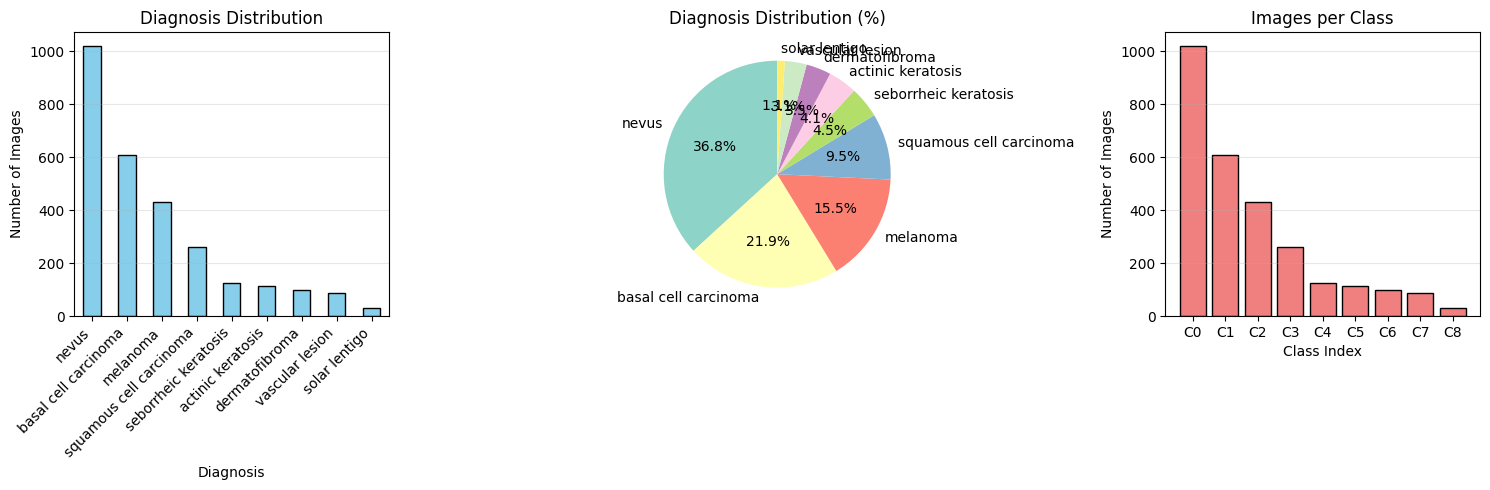


=== Visualizing Sample Images ===
Found 9 unique diagnoses


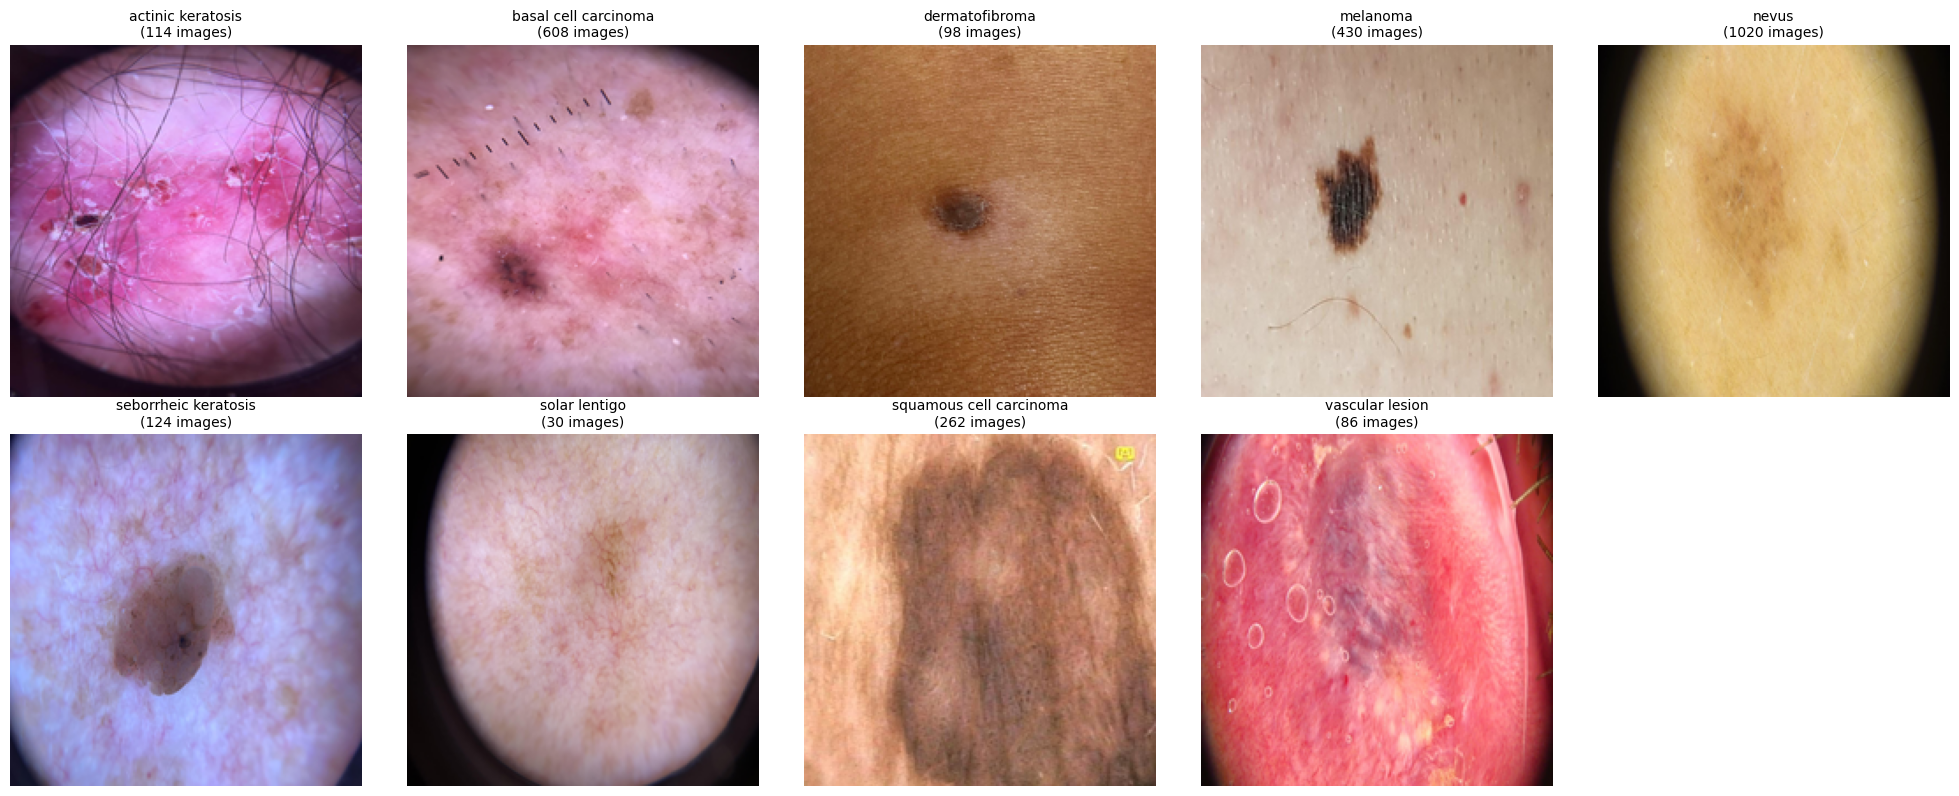


=== Creating Balanced Dataset ===
Target count per class: 1020
Class nevus: 1020 (no augmentation needed)
Class basal cell carcinoma: 608 -> 1020 (+412)
Class melanoma: 430 -> 1020 (+590)
Class squamous cell carcinoma: 262 -> 1020 (+758)
Class seborrheic keratosis: 124 -> 1020 (+896)
Class actinic keratosis: 114 -> 1020 (+906)
Class dermatofibroma: 98 -> 1020 (+922)
Class vascular lesion: 86 -> 1020 (+934)
Class solar lentigo: 30 -> 1020 (+990)

Final balanced dataset: 9180 images

=== Loading Image Pixels ===
Loading images at 224x224 resolution...
Successfully loaded 6408/9180 images

=== Visualizing Augmentation Results ===


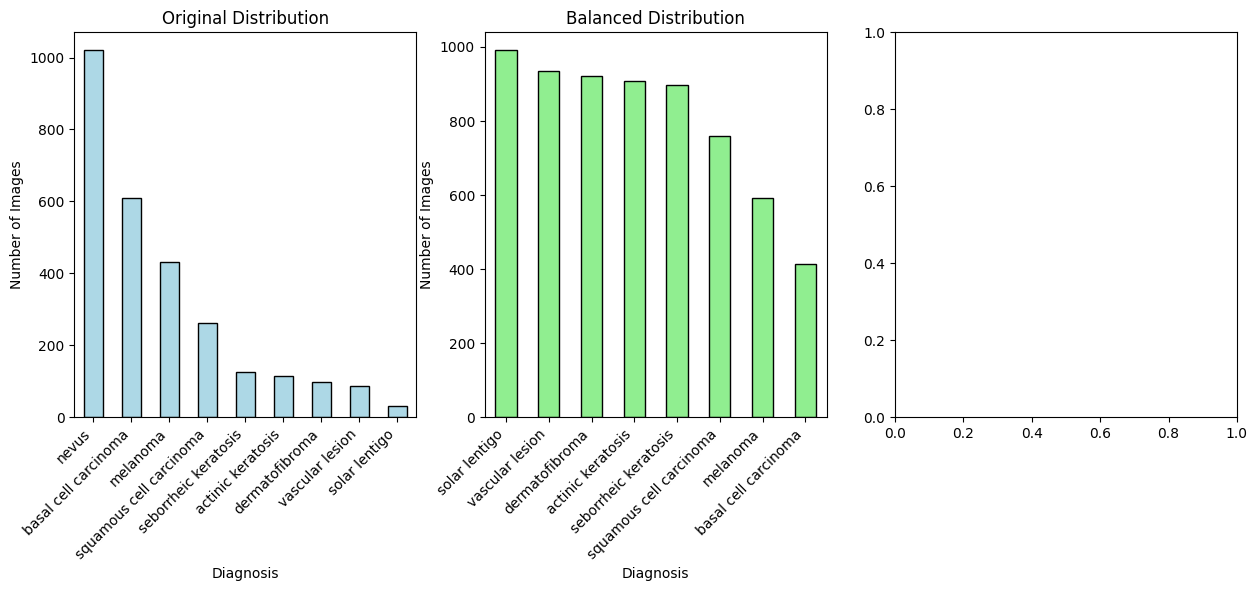

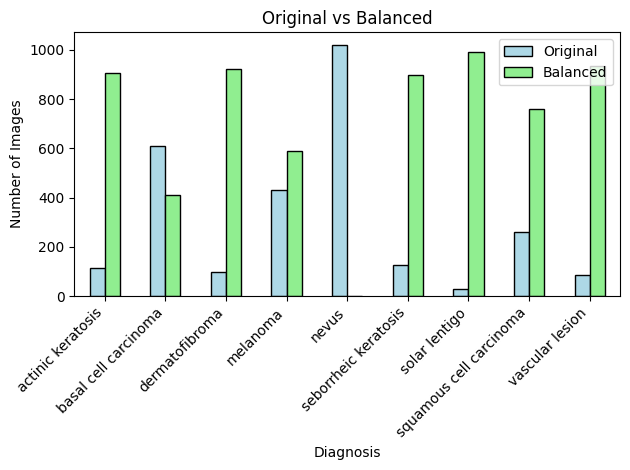


=== Preparing Data for Training ===
X shape: (6408, 224, 224, 3)
y shape: (6408,)
Unique labels: [0 1 2 3 5 6 7 8]
Label distribution: [906 412 922 590   0 896 990 758 934]
Training set: 5126 samples
Test set: 1282 samples

DATASET PREPARATION COMPLETE!
Original dataset: 2772 samples
Balanced dataset: 6408 samples
Number of classes: 9
Training samples: 5126
Test samples: 1282
Image size: 224x224
Ready for model training!


In [14]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
import warnings
import time
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

# Optional imports for enhanced features
try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False
    print("OpenCV not available. Some image processing features will be limited.")

# Configuration
class Config:
    """Configuration settings for the skin cancer classification pipeline"""
    # Image settings
    IMAGE_SIZE = 224  # Standard size for medical images
    BATCH_SIZE = 16   # Reduced batch size for stability
    EPOCHS = 100      # Training epochs
    
    # Model settings
    LEARNING_RATE = 0.0001  # Learning rate
    DROPOUT_RATE = 0.5      # Dropout rate
    
    # Training settings
    VALIDATION_SPLIT = 0.2
    TEST_SPLIT = 0.2
    PATIENCE = 3

config = Config()

def load_hiba_organized_dataset(base_dir):
    """Load and explore the organized HIBA dataset structure"""
    print("=== Loading Organized HIBA Dataset ===")
    print(f"Base directory: {base_dir}")
    
    # Check if base directory exists
    if not os.path.exists(base_dir):
        print(f"ERROR: Base directory does not exist: {base_dir}")
        return None
    
    # Look for class folders
    class_folders = [d for d in os.listdir(base_dir) 
                    if os.path.isdir(os.path.join(base_dir, d))]
    
    if not class_folders:
        print("No class folders found. Trying to load from image files...")
        return create_basic_dataframe_from_images(base_dir)
    
    print(f"Found class folders: {class_folders}")
    
    # Create DataFrame from organized structure
    data_list = []
    for class_name in class_folders:
        class_path = os.path.join(base_dir, class_name)
        
        # Find all images in this class folder
        image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.JPG', '*.JPEG', '*.PNG']
        class_images = []
        
        for ext in image_extensions:
            class_images.extend(glob(os.path.join(class_path, ext)))
        
        print(f"Class '{class_name}': {len(class_images)} images")
        
        # Add to data list
        for img_path in class_images:
            img_name = os.path.splitext(os.path.basename(img_path))[0]
            data_list.append({
                'isic_id': img_name,
                'diagnosis': class_name,
                'image_path': img_path
            })
    
    df = pd.DataFrame(data_list)
    print(f"Created DataFrame with {len(df)} images and {len(class_folders)} classes")
    return df

def create_basic_dataframe_from_images(base_dir):
    """Create a basic DataFrame from image files if no organized structure"""
    # Look for image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']
    all_images = []
    
    for ext in image_extensions:
        all_images.extend(glob(os.path.join(base_dir, ext)))
        all_images.extend(glob(os.path.join(base_dir, "**", ext), recursive=True))
    
    if not all_images:
        print("No images found!")
        return None
    
    # Create basic DataFrame
    data_list = []
    for img_path in all_images:
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        
        # Try to infer diagnosis from folder structure
        parent_dir = os.path.basename(os.path.dirname(img_path))
        if parent_dir != os.path.basename(base_dir):
            diagnosis = parent_dir
        else:
            diagnosis = 'unknown'
        
        data_list.append({
            'isic_id': img_name,
            'diagnosis': diagnosis,
            'image_path': img_path
        })
    
    df = pd.DataFrame(data_list)
    print(f"Created DataFrame with {len(df)} images")
    return df

def preprocess_hiba_data(df):
    """Preprocess the HIBA dataset"""
    print("\n=== Preprocessing Data ===")
    
    if df is None:
        return None
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Drop rows with missing diagnosis
    initial_count = len(df)
    df.dropna(subset=['diagnosis'], inplace=True)
    print(f"Removed {initial_count - len(df)} rows with missing diagnosis")
    
    # Encode 'diagnosis' to numeric labels
    diagnosis_mapping = {label: idx for idx, label in enumerate(df['diagnosis'].unique())}
    df['diagnosis_label'] = df['diagnosis'].map(diagnosis_mapping)
    
    print(f"Diagnosis mapping: {diagnosis_mapping}")
    
    # Check if image paths exist
    if 'image_path' in df.columns:
        existing_paths = df['image_path'].apply(lambda x: os.path.exists(x) if pd.notna(x) else False)
        valid_count = existing_paths.sum()
        print(f"Found {valid_count}/{len(df)} valid image paths")
        
        # Keep only rows with valid image paths
        df = df[existing_paths].copy()
    
    print(f"Final dataset: {len(df)} samples with {len(df['diagnosis'].unique())} unique diagnoses")
    
    return df, diagnosis_mapping

def enhanced_load_image_pixels(image_path, target_size=224):
    """Load and preprocess image with proper medical image handling"""
    if not image_path or not os.path.exists(image_path):
        return None
    
    try:
        # Load image
        image = Image.open(image_path)
        
        # Convert to RGB if needed
        if image.mode != 'RGB':
            image = image.convert('RGB')
        
        # Resize to target size with high-quality resampling
        image = image.resize((target_size, target_size), Image.LANCZOS)
        
        # Convert to numpy array
        img_array = np.asarray(image)
        
        # Optional: Apply basic preprocessing for medical images
        if CV2_AVAILABLE:
            img_array = enhance_medical_image(img_array)
        
        return img_array
        
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def enhance_medical_image(image):
    """Apply medical-specific image enhancement"""
    if not CV2_AVAILABLE:
        return image
    
    # Convert to LAB color space for better contrast enhancement
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    
    # Apply CLAHE to L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    
    # Convert back to RGB
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    return enhanced

def analyze_dataset_distribution(df):
    """Analyze and visualize the dataset distribution"""
    print("\n=== Dataset Analysis ===")
    
    if df is None or len(df) == 0:
        print("No data to analyze")
        return
    
    # Class distribution
    class_counts = df['diagnosis'].value_counts()
    print("Class distribution:")
    for diagnosis, count in class_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {diagnosis}: {count} images ({percentage:.1f}%)")
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    # Bar plot
    plt.subplot(1, 3, 1)
    class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Diagnosis Distribution')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Pie chart
    plt.subplot(1, 3, 2)
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
    plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
    plt.title('Diagnosis Distribution (%)')
    
    # Class comparison
    plt.subplot(1, 3, 3)
    plt.bar(range(len(class_counts)), class_counts.values, color='lightcoral', edgecolor='black')
    plt.title('Images per Class')
    plt.xlabel('Class Index')
    plt.ylabel('Number of Images')
    plt.xticks(range(len(class_counts)), [f"C{i}" for i in range(len(class_counts))])
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return class_counts

def create_balanced_dataset_smart(data):
    """Create balanced dataset using smart augmentation - same as HAM10000"""
    print("\n=== Creating Balanced Dataset ===")
    
    class_counts = data['diagnosis'].value_counts()
    
    # Check if we have only one class
    if len(class_counts) == 1:
        print("Only one class found. No balancing needed.")
        return data
    
    max_count = class_counts.max()
    
    print(f"Target count per class: {max_count}")
    
    balanced_frames = []
    
    for dx in class_counts.index:
        class_data = data[data['diagnosis'] == dx].copy()
        current_count = len(class_data)
        
        if current_count < max_count:
            # Calculate how many more samples we need
            needed = max_count - current_count
            
            # Use smart sampling instead of simple duplication
            additional_samples = create_additional_samples(class_data, needed)
            balanced_frames.append(pd.concat([class_data, additional_samples], ignore_index=True))
            
            print(f"Class {dx}: {current_count} -> {len(balanced_frames[-1])} (+{needed})")
        else:
            balanced_frames.append(class_data)
            print(f"Class {dx}: {current_count} (no augmentation needed)")
    
    # Combine all balanced data
    balanced_data = pd.concat(balanced_frames, ignore_index=True)
    
    print(f"\nFinal balanced dataset: {len(balanced_data)} images")
    
    return balanced_data

def create_additional_samples(class_data, needed_count):
    """Create additional samples using intelligent duplication with variation"""
    additional_samples = []
    
    # Sample with replacement but add some variation
    for i in range(needed_count):
        # Select a random sample from the class
        sample_idx = np.random.randint(0, len(class_data))
        sample = class_data.iloc[sample_idx].copy()
        
        # Add slight variation to avoid exact duplicates
        if 'image_path' in sample:
            # Load and augment the image
            img_array = enhanced_load_image_pixels(sample['image_path'], config.IMAGE_SIZE)
            if img_array is not None:
                # Apply random augmentation to the image
                augmented_image = apply_random_augmentation(img_array)
                # Note: We store the augmented image array, not the path
                sample['image_pixel'] = augmented_image
        
        additional_samples.append(sample)
    
    return pd.DataFrame(additional_samples)

def apply_random_augmentation(image):
    """Apply random augmentation to an image - same as HAM10000"""
    if not CV2_AVAILABLE:
        return image
    
    # Random rotation (-10 to 10 degrees)
    angle = np.random.uniform(-10, 10)
    height, width = image.shape[:2]
    center = (width // 2, height // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, rotation_matrix, (width, height))
    
    # Random brightness adjustment
    brightness = np.random.uniform(0.8, 1.2)
    brightened = np.clip(rotated * brightness, 0, 255).astype(np.uint8)
    
    # Random horizontal flip
    if np.random.random() > 0.5:
        brightened = cv2.flip(brightened, 1)
    
    return brightened

def load_image_pixels_for_dataset(data):
    """Load image pixels for the entire dataset"""
    print(f"\n=== Loading Image Pixels ===")
    print(f"Loading images at {config.IMAGE_SIZE}x{config.IMAGE_SIZE} resolution...")
    
    # Load image pixels for samples that don't already have them
    def load_pixel_data(row):
        if 'image_pixel' in row and row['image_pixel'] is not None:
            return row['image_pixel']  # Already loaded (from augmentation)
        else:
            return enhanced_load_image_pixels(row['image_path'], config.IMAGE_SIZE)
    
    data['image_pixel'] = data.apply(load_pixel_data, axis=1)
    
    # Remove rows with failed image loading
    initial_count = len(data)
    data = data[data['image_pixel'].notnull()]
    final_count = len(data)
    print(f"Successfully loaded {final_count}/{initial_count} images")
    
    if final_count == 0:
        print("ERROR: No images could be loaded successfully!")
        return None
    
    return data

def prepare_data_for_training(data):
    """Prepare data for model training - same as HAM10000"""
    print("\n=== Preparing Data for Training ===")
    
    # Convert image pixels to numpy array
    X = np.stack(data['image_pixel'].values)
    y = np.array(data['diagnosis_label'].values)
    
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Unique labels: {np.unique(y)}")
    print(f"Label distribution: {np.bincount(y)}")
    
    # Check if we have enough samples for splitting
    if len(X) < 10:
        print("WARNING: Very few samples. Consider using all data for training.")
        test_size = 0.1
    else:
        test_size = config.TEST_SPLIT
    
    # Split data with stratification (if possible)
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
    except ValueError:
        # If stratification fails (e.g., too few samples per class)
        print("Warning: Stratification failed, using random split")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    
    # Normalize data manually
    X_train = X_train.astype(np.float32) / 255.0
    X_test = X_test.astype(np.float32) / 255.0
    
    # Create simple data generators with minimal augmentation
    train_datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        horizontal_flip=True,
        validation_split=config.VALIDATION_SPLIT
    )
    
    # Fit the generator
    train_datagen.fit(X_train)
    
    return X_train, X_test, y_train, y_test, train_datagen

def visualize_sample_images(df, max_samples_per_class=1):
    """Visualize sample images for each diagnosis"""
    print(f"\n=== Visualizing Sample Images ===")
    
    if df is None or len(df) == 0:
        print("No data to visualize")
        return
    
    unique_diagnoses = df['diagnosis'].unique()
    n_diagnoses = len(unique_diagnoses)
    
    print(f"Found {n_diagnoses} unique diagnoses")
    
    # Calculate grid size
    cols = min(5, n_diagnoses)
    rows = (n_diagnoses + cols - 1) // cols
    
    plt.figure(figsize=(4*cols, 4*rows))
    
    for i, diagnosis in enumerate(unique_diagnoses):
        # Get samples for this diagnosis
        diagnosis_samples = df[df['diagnosis'] == diagnosis]
        
        if len(diagnosis_samples) == 0:
            continue
        
        # Take first sample
        sample_image = diagnosis_samples.iloc[0]
        img_path = sample_image['image_path']
        
        try:
            # Load and display image
            img = Image.open(img_path)
            
            # Convert to RGB if necessary
            if img.mode != 'RGB':
                img = img.convert('RGB')
            
            # Resize for consistent display
            img = img.resize((200, 200), Image.LANCZOS)
            
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(f"{diagnosis}\n({len(diagnosis_samples)} images)", fontsize=10)
            plt.axis("off")
            
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            plt.subplot(rows, cols, i + 1)
            plt.text(0.5, 0.5, f"Error loading\n{diagnosis}", 
                    ha='center', va='center', transform=plt.gca().transAxes)
            plt.title(f"{diagnosis}\n({len(diagnosis_samples)} images)", fontsize=10)
            plt.axis("off")
    
    plt.tight_layout()
    plt.show()

def visualize_augmented_samples(balanced_data, original_data):
    """Visualize original vs augmented samples"""
    print("\n=== Visualizing Augmentation Results ===")
    
    # Compare class distributions
    plt.figure(figsize=(15, 5))
    
    # Original distribution
    plt.subplot(1, 3, 1)
    original_counts = original_data['diagnosis'].value_counts()
    original_counts.plot(kind='bar', color='lightblue', edgecolor='black')
    plt.title('Original Distribution')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    
    # Balanced distribution
    plt.subplot(1, 3, 2)
    balanced_counts = balanced_data['diagnosis'].value_counts()
    balanced_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title('Balanced Distribution')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    
    # Comparison
    plt.subplot(1, 3, 3)
    comparison_df = pd.DataFrame({
        'Original': original_counts,
        'Balanced': balanced_counts
    }).fillna(0)
    comparison_df.plot(kind='bar', color=['lightblue', 'lightgreen'], edgecolor='black')
    plt.title('Original vs Balanced')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def generate_dataset_summary(df):
    """Generate a comprehensive dataset summary"""
    print("\n=== Dataset Summary ===")
    
    if df is None:
        print("No dataset loaded")
        return
    
    print(f"Total samples: {len(df)}")
    print(f"Total unique diagnoses: {len(df['diagnosis'].unique())}")
    print(f"Columns: {list(df.columns)}")
    
    # Missing values
    missing_data = df.isnull().sum()
    if missing_data.sum() > 0:
        print("\nMissing values:")
        for col, missing_count in missing_data.items():
            if missing_count > 0:
                print(f"  {col}: {missing_count}")
    else:
        print("\nNo missing values found")

def main():
    """Main function to run the HIBA dataset pipeline with augmentation"""
    # Set the base directory (organized images folder)
    base_skin_dir = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HIBA Skin Lesions\sorted images"
    
    print("=== HIBA Dataset Pipeline with Data Augmentation ===")
    
    # Load organized dataset
    df = load_hiba_organized_dataset(base_skin_dir)
    
    if df is None:
        print("Failed to load dataset")
        return None
    
    # Preprocess data
    df, diagnosis_mapping = preprocess_hiba_data(df)
    
    if df is None or len(df) == 0:
        print("No valid data after preprocessing")
        return None
    
    # Generate summary
    generate_dataset_summary(df)
    
    # Analyze original distribution
    print("\n=== Original Dataset Analysis ===")
    original_class_counts = analyze_dataset_distribution(df)
    
    # Visualize original samples
    visualize_sample_images(df, max_samples_per_class=1)
    
    # Create balanced dataset with augmentation
    balanced_data = create_balanced_dataset_smart(df)
    
    # Load image pixels for the balanced dataset
    balanced_data = load_image_pixels_for_dataset(balanced_data)
    
    if balanced_data is None:
        print("Failed to load image pixels")
        return None
    
    # Visualize augmentation results
    visualize_augmented_samples(balanced_data, df)
    
    # Prepare data for training
    X_train, X_test, y_train, y_test, train_datagen = prepare_data_for_training(balanced_data)
    
    print("\n" + "="*60)
    print("DATASET PREPARATION COMPLETE!")
    print("="*60)
    print(f"Original dataset: {len(df)} samples")
    print(f"Balanced dataset: {len(balanced_data)} samples")
    print(f"Number of classes: {len(diagnosis_mapping)}")
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Image size: {config.IMAGE_SIZE}x{config.IMAGE_SIZE}")
    print("Ready for model training!")
    
    return {
        'original_data': df,
        'balanced_data': balanced_data,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'train_datagen': train_datagen,
        'diagnosis_mapping': diagnosis_mapping
    }

# Run the pipeline
if __name__ == "__main__":
    results = main()


=== HIBA Model Comparison Pipeline ===
Number of classes: 9
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'seborrheic keratosis', 'solar lentigo', 'squamous cell carcinoma', 'vascular lesion']

=== Preparing HIBA Data for Training (Memory Efficient) ===
Training set: 5126 samples
Test set: 1282 samples

Starting Custom CNN

Training Custom CNN
Epoch 1/100
320/320 [==============================] - 13s 38ms/step - loss: 2.4618 - accuracy: 0.2064 - val_loss: 2.1681 - val_accuracy: 0.1758 - lr: 1.0000e-04
Epoch 2/100
320/320 [==============================] - 12s 37ms/step - loss: 2.1247 - accuracy: 0.2521 - val_loss: 1.6812 - val_accuracy: 0.3867 - lr: 1.0000e-04
Epoch 3/100
320/320 [==============================] - 12s 37ms/step - loss: 1.9837 - accuracy: 0.2814 - val_loss: 1.6190 - val_accuracy: 0.4395 - lr: 1.0000e-04
Epoch 4/100
320/320 [==============================] - 12s 36ms/step - loss: 1.8906 - accuracy: 0.3094 - val_loss: 1.56

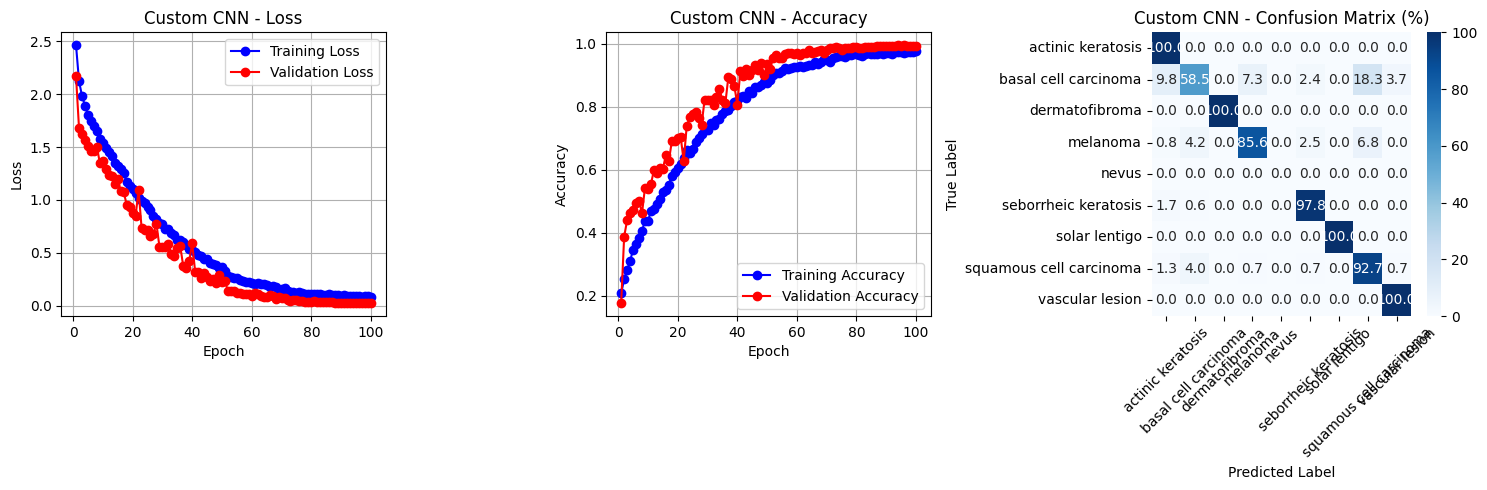


Starting ResNet50

Training ResNet50
Epoch 1/100
320/320 [==============================] - 40s 115ms/step - loss: 1.2442 - accuracy: 0.5977 - val_loss: 15.9203 - val_accuracy: 0.0977 - lr: 1.0000e-04
Epoch 2/100
320/320 [==============================] - 37s 115ms/step - loss: 0.3972 - accuracy: 0.8697 - val_loss: 3.8989 - val_accuracy: 0.1992 - lr: 1.0000e-04
Epoch 3/100
320/320 [==============================] - 37s 115ms/step - loss: 0.2235 - accuracy: 0.9313 - val_loss: 1.4694 - val_accuracy: 0.6982 - lr: 1.0000e-04
Epoch 4/100
320/320 [==============================] - 37s 115ms/step - loss: 0.1525 - accuracy: 0.9575 - val_loss: 0.1658 - val_accuracy: 0.9521 - lr: 1.0000e-04
Epoch 5/100
320/320 [==============================] - 37s 115ms/step - loss: 0.1383 - accuracy: 0.9591 - val_loss: 0.0596 - val_accuracy: 0.9805 - lr: 1.0000e-04
Epoch 6/100
320/320 [==============================] - 37s 115ms/step - loss: 0.0607 - accuracy: 0.9804 - val_loss: 0.0378 - val_accuracy: 0.9873 

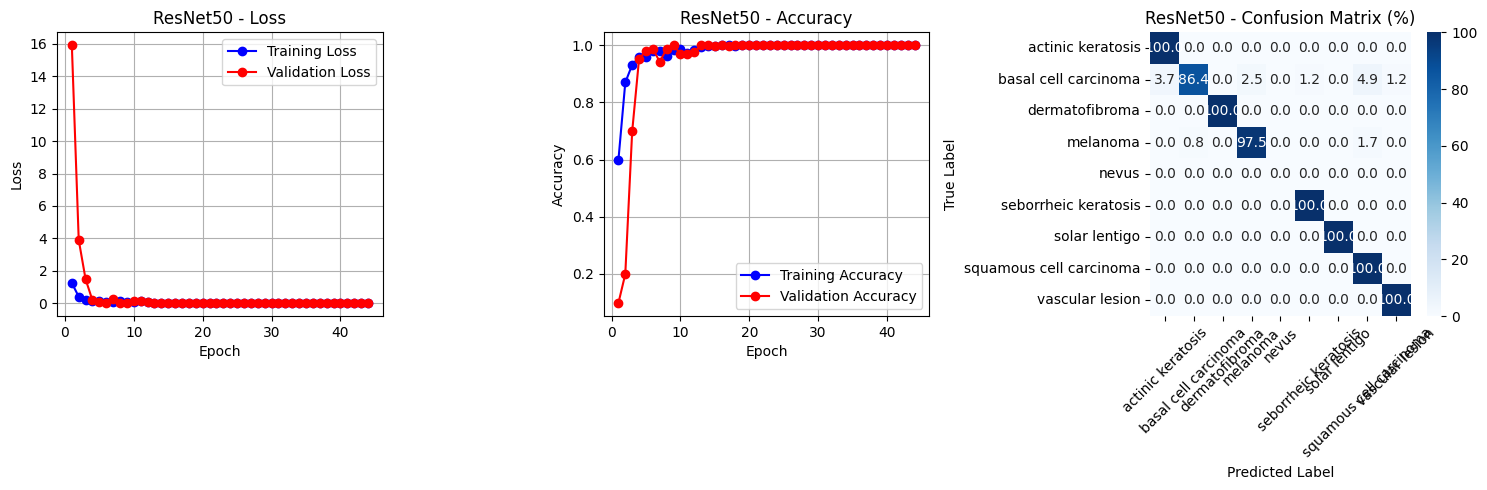


Starting ResNet101

Training ResNet101
Epoch 1/100
320/320 [==============================] - 60s 169ms/step - loss: 1.1527 - accuracy: 0.6150 - val_loss: 2.4956 - val_accuracy: 0.1426 - lr: 1.0000e-04
Epoch 2/100
320/320 [==============================] - 53s 167ms/step - loss: 0.3447 - accuracy: 0.8896 - val_loss: 3.1327 - val_accuracy: 0.2520 - lr: 1.0000e-04
Epoch 3/100
320/320 [==============================] - 53s 167ms/step - loss: 0.2244 - accuracy: 0.9325 - val_loss: 1.7749 - val_accuracy: 0.7568 - lr: 1.0000e-04
Epoch 4/100
320/320 [==============================] - 53s 167ms/step - loss: 0.1735 - accuracy: 0.9532 - val_loss: 0.0467 - val_accuracy: 0.9854 - lr: 1.0000e-04
Epoch 5/100
320/320 [==============================] - 53s 166ms/step - loss: 0.0991 - accuracy: 0.9722 - val_loss: 0.3213 - val_accuracy: 0.9805 - lr: 1.0000e-04
Epoch 6/100
320/320 [==============================] - 53s 166ms/step - loss: 0.1084 - accuracy: 0.9708 - val_loss: 0.0596 - val_accuracy: 0.9883

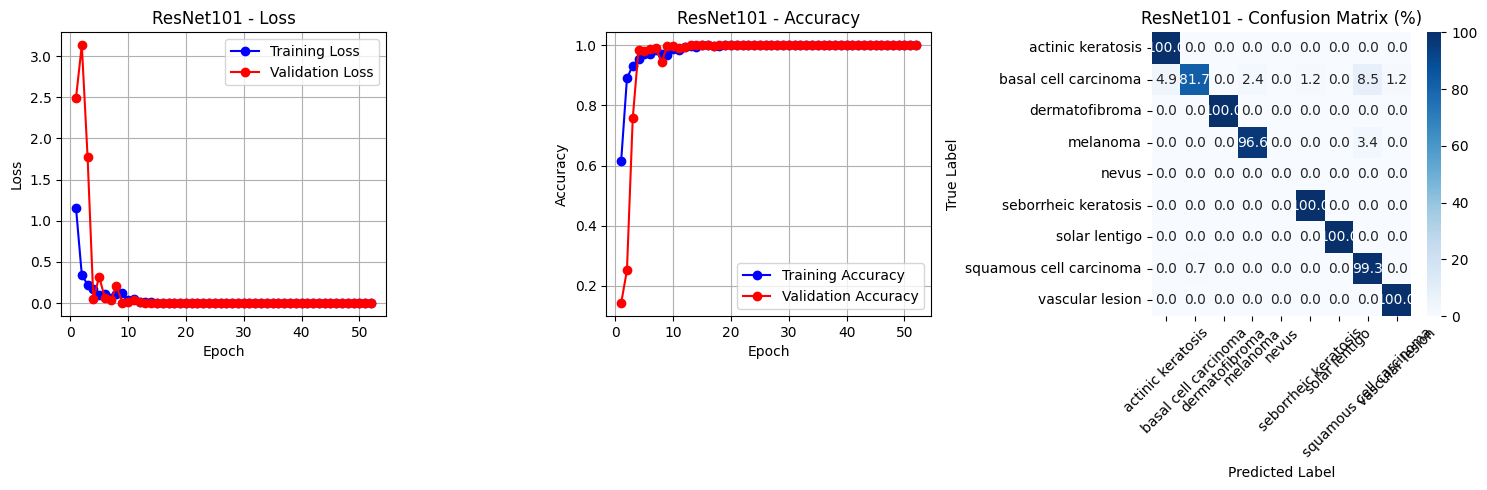


Starting EfficientNet-B0

Training EfficientNet-B0
Epoch 1/100
320/320 [==============================] - 34s 91ms/step - loss: 1.6372 - accuracy: 0.4141 - val_loss: 2.1794 - val_accuracy: 0.1514 - lr: 1.0000e-04
Epoch 2/100
320/320 [==============================] - 28s 88ms/step - loss: 0.8320 - accuracy: 0.7297 - val_loss: 2.3701 - val_accuracy: 0.1953 - lr: 1.0000e-04
Epoch 3/100
320/320 [==============================] - 29s 89ms/step - loss: 0.4828 - accuracy: 0.8352 - val_loss: 2.1978 - val_accuracy: 0.1680 - lr: 1.0000e-04
Epoch 4/100
320/320 [==============================] - 29s 89ms/step - loss: 0.3039 - accuracy: 0.9018 - val_loss: 2.0561 - val_accuracy: 0.3408 - lr: 1.0000e-04
Epoch 5/100
320/320 [==============================] - 29s 90ms/step - loss: 0.1966 - accuracy: 0.9386 - val_loss: 2.0369 - val_accuracy: 0.3389 - lr: 1.0000e-04
Epoch 6/100
320/320 [==============================] - 28s 89ms/step - loss: 0.1352 - accuracy: 0.9568 - val_loss: 0.4874 - val_accuracy: 

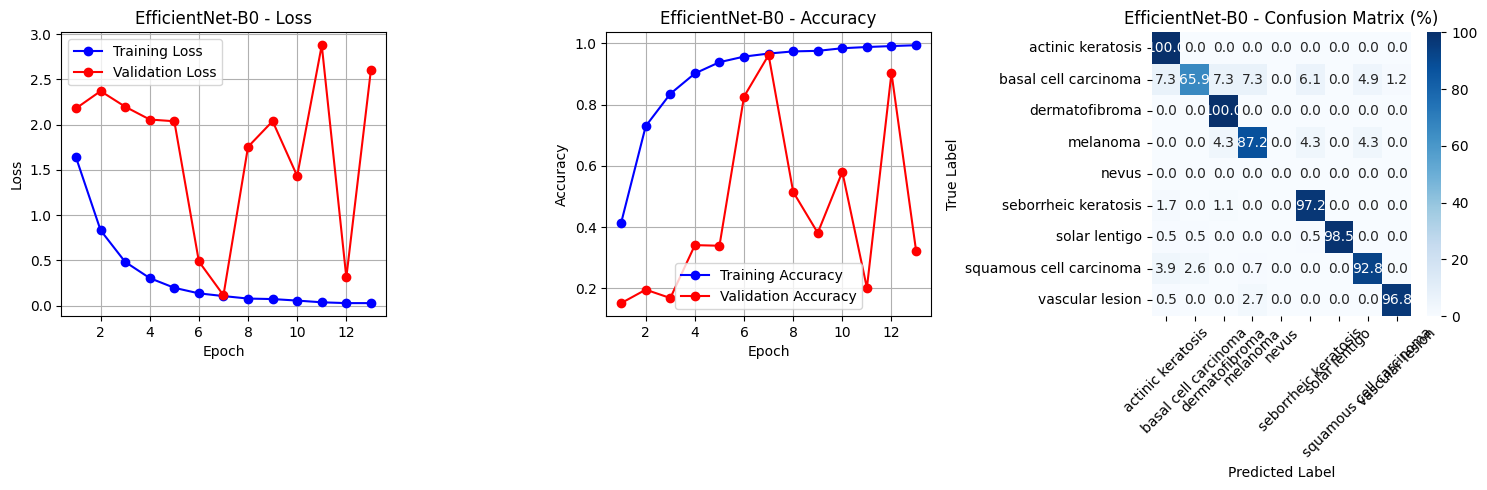


SUMMARY OF ALL MODELS - HIBA DATASET
Custom CNN      | Accuracy: 0.948 | Train Time: 1188.03s | Test Time: 5.18s
ResNet50        | Accuracy: 0.989 | Train Time: 1609.58s | Test Time: 8.48s
ResNet101       | Accuracy: 0.984 | Train Time: 2764.24s | Test Time: 11.08s
EfficientNet-B0 | Accuracy: 0.947 | Train Time: 374.36s | Test Time: 7.65s


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, BatchNormalization, Dropout, Dense, MaxPool2D, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import gc

EPOCHS = 100

def create_custom_cnn(num_classes):
    """Create custom CNN with dynamic number of classes"""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3)),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPool2D(2, 2),
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(num_classes, activation='softmax')
    ])
    return model

def create_resnet50(num_classes):
    """Create ResNet50 with dynamic number of classes"""
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3))
    for layer in base_model.layers[-10:]:
        layer.trainable = True
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(num_classes, activation='softmax')
    ])
    return model

def create_resnet101(num_classes):
    """Create ResNet101 with dynamic number of classes"""
    base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3))
    for layer in base_model.layers[-15:]:
        layer.trainable = True
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(num_classes, activation='softmax')
    ])
    return model

def create_efficientnet(num_classes):
    """Create EfficientNet with dynamic number of classes"""
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3))
    for layer in base_model.layers[-20:]:
        layer.trainable = True
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(num_classes, activation='softmax')
    ])
    return model

def compile_model(model):
    """Compile model with appropriate optimizer and loss function"""
    model.compile(
        optimizer=Adam(learning_rate=config.LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def prepare_data_for_training_hiba(balanced_data):
    """Memory-efficient data preparation using generators for HIBA dataset"""
    print("\n=== Preparing HIBA Data for Training (Memory Efficient) ===")
    
    # Check if we have enough samples for splitting
    if len(balanced_data) < 10:
        print("WARNING: Very few samples. Consider using all data for training.")
        test_size = 0.1
    else:
        test_size = config.TEST_SPLIT
    
    # Split data with stratification (if possible)
    try:
        train_data, test_data = train_test_split(
            balanced_data, test_size=test_size, random_state=42, stratify=balanced_data['diagnosis_label']
        )
    except ValueError:
        # If stratification fails (e.g., too few samples per class)
        print("Warning: Stratification failed, using random split")
        train_data, test_data = train_test_split(
            balanced_data, test_size=test_size, random_state=42
        )
    
    print(f"Training set: {len(train_data)} samples")
    print(f"Test set: {len(test_data)} samples")
    
    train_datagen = ImageDataGenerator(
        rescale=1.0/255.0,
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        horizontal_flip=True,
        validation_split=config.VALIDATION_SPLIT
    )
    
    test_datagen = ImageDataGenerator(rescale=1.0/255.0)
    
    return train_data, test_data, train_datagen, test_datagen

def create_custom_generator_hiba(data, batch_size=16, target_size=(224, 224)):
    """Custom generator that loads images on demand for HIBA dataset"""
    while True:
        indices = np.random.permutation(len(data))
        for i in range(0, len(data), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_data = data.iloc[batch_indices]
            
            batch_x = []
            batch_y = []
            
            for _, row in batch_data.iterrows():
                # Check if image_pixel exists (from augmentation) or load from path
                if 'image_pixel' in row and row['image_pixel'] is not None:
                    img = row['image_pixel']
                else:
                    img = enhanced_load_image_pixels(row['image_path'], target_size[0])
                
                if img is not None:
                    batch_x.append(img)
                    batch_y.append(row['diagnosis_label'])
            
            if len(batch_x) > 0:
                batch_x = np.array(batch_x).astype(np.float32) / 255.0
                batch_y = np.array(batch_y)
                yield batch_x, batch_y

def train_and_evaluate_model_hiba(model, model_name, train_data, test_data, diagnosis_mapping):
    """Train and evaluate a model for HIBA dataset"""
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")
    
    # Calculate steps
    train_steps = max(1, len(train_data) // config.BATCH_SIZE)
    val_data_size = max(1, int(len(train_data) * config.VALIDATION_SPLIT))
    val_steps = max(1, val_data_size // config.BATCH_SIZE)
    test_steps = max(1, len(test_data) // config.BATCH_SIZE)
    
    # Create generators
    train_generator = create_custom_generator_hiba(train_data, config.BATCH_SIZE)
    val_generator = create_custom_generator_hiba(
        train_data.sample(val_data_size, random_state=42), config.BATCH_SIZE
    )
    test_generator = create_custom_generator_hiba(test_data, config.BATCH_SIZE)
    
    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=config.PATIENCE * 2,  # Increased patience for stability
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=config.PATIENCE,
        min_lr=1e-7,
        verbose=1
    )
    
    # Training
    start_time = time.time()
    history = model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        epochs=EPOCHS,
        validation_data=val_generator,
        validation_steps=val_steps,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    training_time = time.time() - start_time
    
    # Evaluation
    start_time = time.time()
    test_loss, test_accuracy = model.evaluate(test_generator, steps=test_steps, verbose=0)
    
    # Predictions for detailed analysis
    y_pred_list = []
    y_true_list = []
    for i, (batch_x, batch_y) in enumerate(test_generator):
        if i >= test_steps:
            break
        batch_pred = model.predict(batch_x, verbose=0)
        y_pred_list.extend(np.argmax(batch_pred, axis=1))
        y_true_list.extend(batch_y)
    
    y_pred = np.array(y_pred_list)
    y_test = np.array(y_true_list)
    testing_time = time.time() - start_time
    
    # Results analysis
    cm = confusion_matrix(y_test, y_pred)
    cm_percentage = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100
    
    print(f"\nTraining Time: {training_time:.2f} seconds")
    print(f"Testing Time: {testing_time:.2f} seconds")
    print(f"Test Accuracy: {test_accuracy:.3f}")
    
    print(f"\nConfusion Matrix (Percentage) for {model_name}:")
    print(cm_percentage)
    
    # Classification report with proper label names
    # Create reverse mapping from label to class name
    reverse_mapping = {v: k for k, v in diagnosis_mapping.items()}
    
    # Get unique labels that actually appear in test data
    unique_test_labels = np.unique(np.concatenate([y_test, y_pred]))
    actual_class_names = [reverse_mapping[i] for i in unique_test_labels]
    
    # Create labels parameter for classification_report to handle missing classes
    labels = list(range(len(diagnosis_mapping)))
    all_class_names = [reverse_mapping[i] for i in range(len(diagnosis_mapping))]
    
    report = classification_report(y_test, y_pred, labels=labels, target_names=all_class_names, digits=3, zero_division=0)
    print(f"\nClassification Report for {model_name}:")
    print(report)
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    # Loss plot
    plt.subplot(1, 3, 1)
    epochs_range = range(1, len(history.history['loss']) + 1)
    plt.plot(epochs_range, history.history['loss'], 'bo-', label='Training Loss')
    plt.plot(epochs_range, history.history['val_loss'], 'ro-', label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history.history['accuracy'], 'bo-', label='Training Accuracy')
    plt.plot(epochs_range, history.history['val_accuracy'], 'ro-', label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Confusion matrix heatmap
    plt.subplot(1, 3, 3)
    
    # Handle case where confusion matrix might be smaller than expected number of classes
    expected_size = len(diagnosis_mapping)
    actual_size = cm_percentage.shape[0]
    
    if actual_size < expected_size:
        # Pad the confusion matrix with zeros for missing classes
        padded_cm = np.zeros((expected_size, expected_size))
        unique_labels = np.unique(np.concatenate([y_test, y_pred]))
        for i, label in enumerate(unique_labels):
            for j, pred_label in enumerate(unique_labels):
                padded_cm[label, pred_label] = cm_percentage[i, j]
        cm_to_plot = padded_cm
        all_class_names = [reverse_mapping[i] for i in range(len(diagnosis_mapping))]
    else:
        cm_to_plot = cm_percentage
        all_class_names = [reverse_mapping[i] for i in range(actual_size)]
    
    sns.heatmap(cm_to_plot, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=all_class_names, yticklabels=all_class_names)
    plt.title(f'{model_name} - Confusion Matrix (%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Clean up memory
    del model
    tf.keras.backend.clear_session()
    gc.collect()
    
    return history, training_time, testing_time, test_accuracy

def run_hiba_model_comparison(balanced_data, diagnosis_mapping):
    """Run comparison of different models on HIBA dataset"""
    print("\n=== HIBA Model Comparison Pipeline ===")
    
    # Get number of classes
    num_classes = len(diagnosis_mapping)
    print(f"Number of classes: {num_classes}")
    print(f"Classes: {list(diagnosis_mapping.keys())}")
    
    # Prepare data
    train_data, test_data, train_datagen, test_datagen = prepare_data_for_training_hiba(balanced_data)
    
    # Model configurations
    models_config = [
        (create_custom_cnn, "Custom CNN"),
        (create_resnet50, "ResNet50"),
        (create_resnet101, "ResNet101"),
        (create_efficientnet, "EfficientNet-B0")
    ]
    
    results = {}
    
    for model_func, model_name in models_config:
        print(f"\n{'='*60}")
        print(f"Starting {model_name}")
        print(f"{'='*60}")
        
        try:
            model = compile_model(model_func(num_classes))
            history, train_time, test_time, test_acc = train_and_evaluate_model_hiba(
                model, model_name, train_data, test_data, diagnosis_mapping
            )
            results[model_name] = {
                'history': history,
                'train_time': train_time,
                'test_time': test_time,
                'test_accuracy': test_acc
            }
        except Exception as e:
            print(f"Error training {model_name}: {e}")
            results[model_name] = {
                'error': str(e),
                'test_accuracy': 0.0,
                'train_time': 0.0,
                'test_time': 0.0
            }
    
    # Summary
    print(f"\n{'='*60}")
    print("SUMMARY OF ALL MODELS - HIBA DATASET")
    print(f"{'='*60}")
    for name, result in results.items():
        if 'error' in result:
            print(f"{name:15} | ERROR: {result['error']}")
        else:
            print(f"{name:15} | Accuracy: {result['test_accuracy']:.3f} | Train Time: {result['train_time']:.2f}s | Test Time: {result['test_time']:.2f}s")
    
    return results

# Run the model comparison (assuming you have the results from the previous pipeline)
# Extract the necessary data from the previous pipeline results
balanced_data = results['balanced_data']
diagnosis_mapping = results['diagnosis_mapping']

# Run model training and comparison
model_results = run_hiba_model_comparison(balanced_data, diagnosis_mapping)